In [1]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt  

In [4]:
# ==========================================
# CONFIGURATION
# ==========================================
# REPLACE THIS with the direct path to any .nii or .nii.gz file
# Example: "./BraTS2023_Training/BraTS-GLI-00000-000/BraTS-GLI-00000-000-t2f.nii.gz"
FILE_PATH = "./ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-00000-000/BraTS-GLI-00000-000-t1c.nii.gz"

Loading: BraTS-GLI-00000-000-t1c.nii.gz...
Shape: (240, 240, 155)
Data Type: float64
Min: 0.0, Max: 12343.0


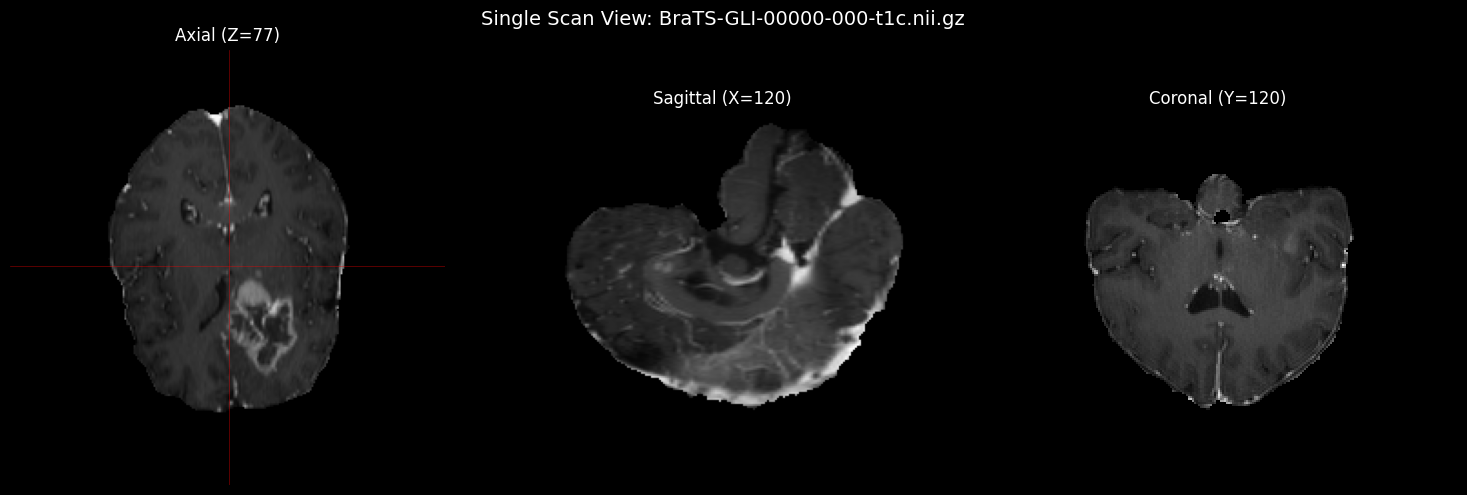

In [5]:
def view_orthogonal_slices(filepath):
    """
    Loads a single NIfTI file and displays the middle slice
    from all three anatomical planes (Axial, Sagittal, Coronal).
    """
    
    # 1. Validation
    if not os.path.exists(filepath):
        print(f"Error: File not found at {filepath}")
        return

    print(f"Loading: {os.path.basename(filepath)}...")

    # 2. Load the file
    img = nib.load(filepath)
    data = img.get_fdata()
    
    # Basic Metadata
    print(f"Shape: {data.shape}")
    print(f"Data Type: {data.dtype}")
    print(f"Min: {np.min(data)}, Max: {np.max(data)}")

    # 3. Calculate Middle Slices
    # Shape is usually (240, 240, 155) -> (x, y, z)
    x_center = data.shape[0] // 2
    y_center = data.shape[1] // 2
    z_center = data.shape[2] // 2

    # 4. Prepare Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    plt.style.use('dark_background') # Looks better for MRI
    fig.patch.set_facecolor('black')

    # --- Axial View (Top-Down) ---
    # Slicing the Z-axis
    axial = data[:, :, z_center].T 
    axes[0].imshow(axial, cmap='gray', origin='lower')
    axes[0].set_title(f"Axial (Z={z_center})", color='white')
    axes[0].axis('off')
    # Draw crosshairs
    axes[0].axhline(y_center, color='r', linewidth=0.5, alpha=0.5)
    axes[0].axvline(x_center, color='r', linewidth=0.5, alpha=0.5)

    # --- Sagittal View (Side Profile) ---
    # Slicing the X-axis
    # Note: We rotate it 90 degrees to make it stand upright
    sagittal = np.rot90(data[x_center, :, :])
    axes[1].imshow(sagittal, cmap='gray', origin='lower')
    axes[1].set_title(f"Sagittal (X={x_center})", color='white')
    axes[1].axis('off')

    # --- Coronal View (Front Face) ---
    # Slicing the Y-axis
    coronal = np.rot90(data[:, y_center, :])
    axes[2].imshow(coronal, cmap='gray', origin='lower')
    axes[2].set_title(f"Coronal (Y={y_center})", color='white')
    axes[2].axis('off')

    plt.suptitle(f"Single Scan View: {os.path.basename(filepath)}", color='white', fontsize=14)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # You can also use this script from command line if needed
    # usage: python single_scan_viewer.py
    view_orthogonal_slices(FILE_PATH)